

# Підготовка даних до аналізу






<h2>Мета</h2>

Ознайомитись з методикою первинної обробки даних. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати структуру завантажених даних
* Виправляти формати даних
* Знаходити та заповнювати пропуски в даних
* Знаходити викиди та некоректні значення
* Будувати прості візуалізації




<a name="task"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>





1. Скачати дані із файлу, записати у dataframe. Дослідити структуру даних.
2. Виправити помилки в даних.
3. Побудувати діаграми розмаху та гістограми.
4. Заповнити пропуски.
5. Додати стовпчик із щільністю населення.



<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити структуру даних</p>
</div>


Зчитую дані з файлу у датафрейм


In [1]:
import pandas as pd

In [2]:
file_path = "Data2.csv"
df = pd.read_csv(filepath_or_buffer=file_path, sep=';', encoding='cp1252')

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
DATA_PATH = 'data/Data2.csv'

# Зчитуємо файл із заданим розділяючим символом ";"
df = pd.read_csv(DATA_PATH, sep=';')

'''
Зауваження: попередній код зчитування з файлу підходить для
файлів з кодуванням utf-8. Проте файл Data2.csv спочатку мав інше
кодування. Дане кодування потрібно вказати в якості параметру:
    
'''

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')


```
</details>




Досліджую структуру даних


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    217 non-null    object 
 1   Region          217 non-null    object 
 2   GDP per capita  190 non-null    object 
 3   Populatiion     216 non-null    float64
 4   CO2 emission    205 non-null    object 
 5   Area            216 non-null    object 
dtypes: float64(1), object(5)
memory usage: 10.3+ KB


In [4]:
df.describe() # int або float

,Populatiion
count,2.160000e+02
mean,4.338952e+07
std,1.879574e+08
min,1.109700e+04
25%,7.900265e+05
50%,6.318988e+06
75%,2.380373e+07
max,1.960424e+09


In [5]:
df.describe(include = "all")

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
count,217,217,190,2.160000e+02,205,216
unique,217,7,190,NaN,202,212
top,Afghanistan,Europe & Central Asia,"561,7787463",NaN,"6318,241",460
freq,1,58,1,NaN,2,3
mean,NaN,NaN,NaN,4.338952e+07,NaN,NaN
std,NaN,NaN,NaN,1.879574e+08,NaN,NaN
min,NaN,NaN,NaN,1.109700e+04,NaN,NaN
25%,NaN,NaN,NaN,7.900265e+05,NaN,NaN
50%,NaN,NaN,NaN,6.318988e+06,NaN,NaN
75%,NaN,NaN,NaN,2.380373e+07,NaN,NaN


In [6]:
df.head(10)
# df.head(50)
# df.tail(50)

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
0,Afghanistan,South Asia,"561,7787463",34656032.0,"9809,225",652860
1,Albania,Europe & Central Asia,"4124,98239",2876101.0,"5716,853",28750
2,Algeria,Middle East & North Africa,"3916,881571",40606052.0,"145400,217",2381740
3,American Samoa,East Asia & Pacific,"11834,74523",55599.0,NaN,200
4,Andorra,Europe & Central Asia,"36988,62203",77281.0,"462,042",470
5,Angola,Sub-Saharan Africa,"3308,700233",28813463.0,"34763,16",1246700
6,Antigua and Barbuda,Latin America & Caribbean,"14462,17628",100963.0,"531,715",440
7,Argentina,Latin America & Caribbean,"12440,32098",43847430.0,"204024,546",2780400
8,Armenia,Europe & Central Asia,"3614,688357",2924816.0,"5529,836",29740
9,Aruba,Latin America & Caribbean,NaN,104822.0,"872,746",180


In [7]:
print(df.isnull().sum())

Country Name       0
Region             0
GDP per capita    27
Populatiion        1
CO2 emission      12
Area               1
dtype: int64


In [8]:
df[df["Area"].astype(str).str.replace(",", ".").astype(float) < 0]

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
135,Myanmar,East Asia & Pacific,"1195,515372",52885223.0,"21631,633",-676590


In [9]:
df[df["GDP per capita"].astype(str).str.replace(",", ".").astype(float) < 0] 

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
56,Dominican Republic,Latin America & Caribbean,"-6722,223536",10648791.0,"21539,958",48670


In [10]:
df[df.duplicated(keep=False)] # перевірка на дублікати (keep=False - показати всі дублікати)

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area


Бачу наступні проблеми в даних:
1. У числових значеннях використано **кому** замість **крапки** як десятковий роздільник;
2. Некоректна назва стовпця **"Populatiion"** (орфографічна помилка замість **"Population"**);
3. У деяких рядках є **від’ємні значення** числових колонок, що є помилкою в даних. Наприклад, у колонці `GDP per capita` для *Dominican Republic*: **-6,722**, а у колонці `Area` для *Myanmar*: **-676,590**. Це означає, що відповідні числові показники некоректні, оскільки населення, площа чи ВВП не можуть бути від’ємними;
4. Колонка `GDP per capita` має тип даних **object**, хоча в ній зберігаються **числові значення**, які повинні бути типу **float**. Аналогічно, колонка `CO2 emission` також має тип **object**, хоча містить числові дані. Колонка `Area` теж повинна мати тип **float**, але наразі зберігається як **object**. Єдиною числовою колонкою з правильним типом **float** є  `Populatiion`. Проте після видалення пропущених значень краще привести цю колонку до типу **int**. Крім того, варто привести до типу **string** такі колонки: `Country Name` та `Region`;
6. Є **пропущені значення** (*NaN*) у таких колонках: `GDP per capita`, `Populatiion`, `CO2 emission`, `Area`.

<a name="task2"></a> <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2"> Завдання  #2: </h2>

<p>Виправити помилки в даних</p>
</div>


**Проблема 1. Неправильні назви**

Для виправлення зроблю наступне: зміню назву стовпця `Populatiion` на правильну `Population`, за допомогою методу `df.rename(columns={'старе_імʼя': 'нове_імʼя'})`:

In [11]:
df = df.rename(columns={"Populatiion" : "Population"})

**Проблема 2. Виправити типи даних у стовпцях датасету**

Для виправлення зроблю наступне:
1. Для початку необхідно замінити десятковий роздільник у числових значеннях, які наразі мають тип даних **object**, з крапки на кому, щоб надалі коректно перетворити їх тип даних на **float**. Якщо цього не зробити, під час зміни типу даних виникатиме помилка через некоректний формат числових значень;
2. Перетворити колонки `GDP per capita`, `CO2 emission` та `Area` на тип **float**, а `Country Name` та `Region` на **string** для коректної обробки даних.

In [12]:
# 1
columns = ["GDP per capita", "CO2 emission", "Area"]
for column in columns:
    df[column] = df[column].str.replace(",", ".")

In [13]:
# 2 
df = df.fillna(0) # заповнюємо всі пропущені значення нулями (Для відображення графіку та зміни типу)

df["Country Name"] = df["Country Name"].astype("string")
df["Region"] = df["Region"].astype("string")
df["GDP per capita"] = df["GDP per capita"].astype(float)
df["CO2 emission"] = df["CO2 emission"].astype(float)
df["Area"] = df["Area"].astype(float)
df['Population'] = df['Population'].astype(int)

df.dtypes

Country Name      string[python]
Region            string[python]
GDP per capita           float64
Population                 int64
CO2 emission             float64
Area                     float64
dtype: object

In [14]:
df.head() # Перевірка

,Country Name,Region,GDP per capita,Population,CO2 emission,Area
0,Afghanistan,South Asia,561.778746,34656032,9809.225,652860.0
1,Albania,Europe & Central Asia,4124.982390,2876101,5716.853,28750.0
2,Algeria,Middle East & North Africa,3916.881571,40606052,145400.217,2381740.0
3,American Samoa,East Asia & Pacific,11834.745230,55599,0.000,200.0
4,Andorra,Europe & Central Asia,36988.622030,77281,462.042,470.0


**Проблема 3. Неправильні значення (занадто великі або занадто малі)**

Для виправлення зроблю наступне:
1. Виправлю негативні значення в стовпці `GDP per capita`, виявивши рядки з `df['GDP per capita'] < 0` і замінивши їх на абсолютні значення через `df.loc[маска, 'GDP per capita'].abs()`;
2. Виправлю негативні значення в стовпці `Area`, виявивши рядки з `df['Area'] < 0` і замінивши їх на абсолютні значення через `df.loc[маска, 'Area'].abs()`.

In [15]:
# DataFrame.loc[condition, column_name] = new_value
df.loc[df['GDP per capita'] < 0, 'GDP per capita'] = df.loc[df['GDP per capita'] < 0, 'GDP per capita'].abs()
df.loc[df["Area"] < 0, "Area"] = df.loc[df["Area"] < 0, "Area"].abs()

<a name="task3"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5"> Завдання  #3: </h2>

<p>Побудувати діаграми розмаху та гістограми</p>
</div>


Для побудови графіків скористайтесь бібліотекою Matplotlib. Спробуйте погратись з кольорами, розмірами та підписами.


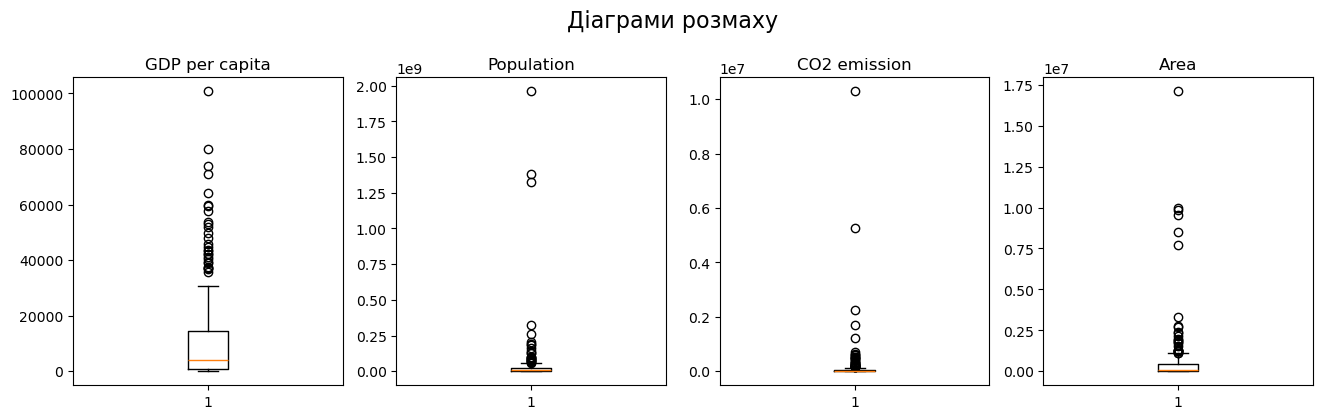

In [16]:
import matplotlib.pyplot as plt

# діагарма розмаху
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16, y=1.05)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['Population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['Area'])

plt.show()

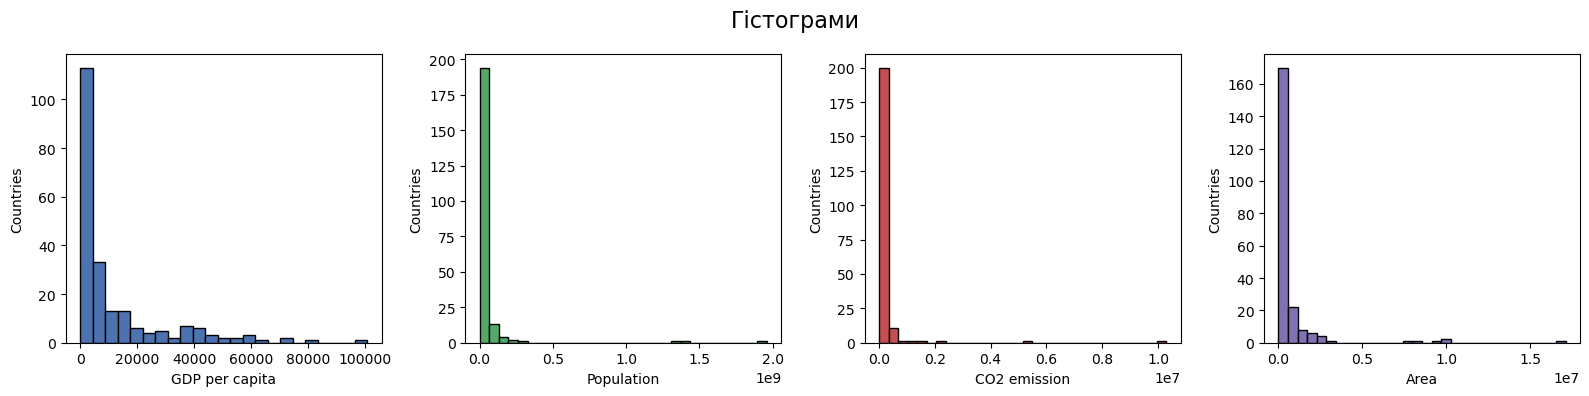

In [17]:
import matplotlib.pyplot as plt

# Створюємо фігуру з 4 осями в ряд
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle("Гістограми", fontsize=16)  # заголовок для всієї фігури

axs[0].hist(df["GDP per capita"], bins="auto", color="#4C72B0", edgecolor="black")
axs[0].set_xlabel("GDP per capita")
axs[0].set_ylabel("Countries")

axs[1].hist(df["Population"], bins="auto", color="#55A868", edgecolor="black")
axs[1].set_xlabel("Population")
axs[1].set_ylabel("Countries")

axs[2].hist(df["CO2 emission"], bins="auto", color="#C44E52", edgecolor="black")
axs[2].set_xlabel("CO2 emission")
axs[2].set_ylabel("Countries")

axs[3].hist(df["Area"], bins="auto", color="#8172B3", edgecolor="black")
axs[3].set_xlabel("Area")
axs[3].set_ylabel("Countries")


plt.tight_layout() 
plt.show()

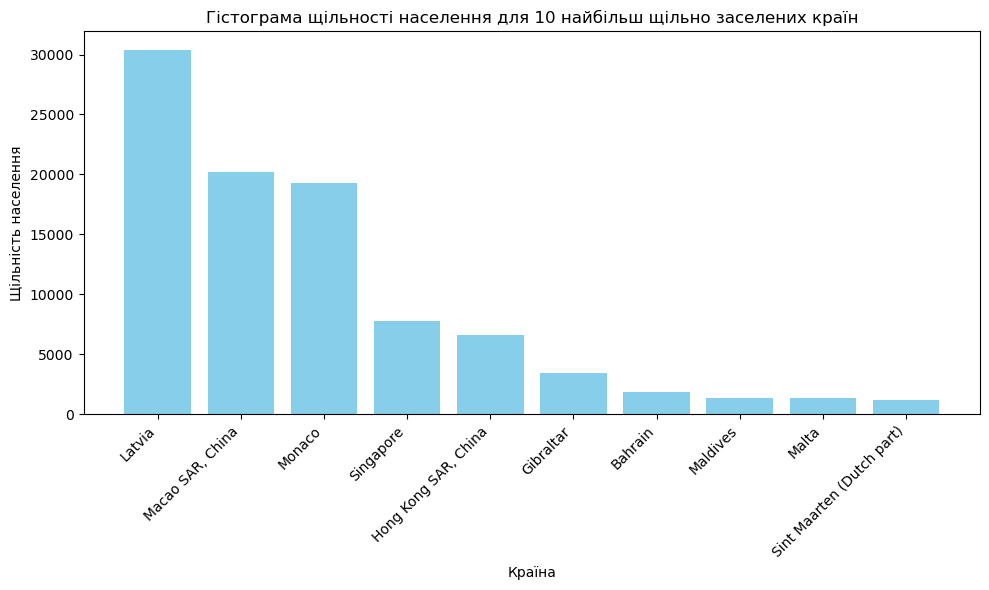

In [25]:
sorted_by_density_df = df.sort_values(by="Population Density", ascending=False)
top_10_countries_density = sorted_by_density_df.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_10_countries_density["Country Name"], 
        top_10_countries_density["Population Density"], 
        color="skyblue")

plt.title("Гістограма щільності населення для 10 найбільш щільно заселених країн")
plt.xlabel("Країна")
plt.ylabel("Щільність населення")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**PS:** <br>   Я побудував цю гістограму, щоб візуально перевірити дані, оскільки під час виконання додаткового завдання помітив дуже дивні показники щільності населення. Розрахунки видали підозріло великі цифри для країн, які насправді не є густонаселеними, тому я вирішив вивести топ-10 на графік. Це допомогло одразу побачити аномалію з Латвією, яка помилково опинилася на першому місці з величезним відривом навіть від Монако. Як виявилося, у таблиці була помилка в колонці населення.

In [31]:
df[df["Country Name"] == "Latvia"]

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population Density
108,Latvia,Europe & Central Asia,14071.02723,1840000.0,6974.634,64490.0,30398.883548


In [32]:
df.loc[df['Country Name'] == 'Latvia', 'Population'] = 1840000

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
# Імпортуємо бібліотеку Matplotlib
import matplotlib.pyplot as plt
    
# діаграми розмаху для "GDP per capita", "Population", "CO2 emission" та "Area"

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['Population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['Area'])

plt.show()

```
</details>




<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3"> Завдання  #4: </h2>
<b>Проблема 4. Пропущені значення </b>
<p>Як найкраще заповнити пропуски підкажуть візуалізації з попереднього завдання.</p>
</div>


Дослідивши гістограму, я побачив правосторонню асиметрію для всіх ознак. Більшість значень зосереджена зліва, а справа видно довгі «хвости» та поодинокі викиди. Це означає, що в даних є кілька дуже великих значень, які відрізняються від основної маси. У такій ситуації середнє арифметичне зміщується в бік більших значень, бо воно чутливе до викидів. Тому для заповнення пропусків краще використовувати медіану, оскільки вона менш залежить від крайніх значень і точніше відображає типове значення в асиметричних даних.

In [18]:
import numpy as np

In [19]:
df["GDP per capita"] = df["GDP per capita"].replace(0, np.nan)
df["GDP per capita"] = df["GDP per capita"].fillna(df.groupby("Region")["GDP per capita"].transform("median"))

In [20]:
df["Population"] = df["Population"].replace(0, np.nan)
df["Population"] = df["Population"].fillna(df.groupby("Region")["Population"].transform("median"))

In [21]:
df["CO2 emission"] = df["CO2 emission"].replace(0, np.nan)
df["CO2 emission"] = df["CO2 emission"].fillna(df.groupby("Region")["CO2 emission"].transform("median"))

In [22]:
df["Area"] = df["Area"].replace(0, np.nan)
df["Area"] = df["Area"].fillna(df.groupby("Region")["Area"].transform("median"))

In [23]:
# Обчислюємо медіану Population по кожному регіону
# Раніше в даних було одне пропущене або нульове значення,
# тепер воно заповнене медианою свого регіону (1268671.0)
# df.groupby("Region")["Population"].median()
# df[df["Population"] == 1268671.0]
df.head(10)
# df.dtypes

,Country Name,Region,GDP per capita,Population,CO2 emission,Area
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0
5,Angola,Sub-Saharan Africa,3308.700233,28813463.0,34763.160,1246700.0
6,Antigua and Barbuda,Latin America & Caribbean,14462.176280,100963.0,531.715,440.0
7,Argentina,Latin America & Caribbean,12440.320980,43847430.0,204024.546,2780400.0
8,Armenia,Europe & Central Asia,3614.688357,2924816.0,5529.836,29740.0
9,Aruba,Latin America & Caribbean,7456.658934,104822.0,872.746,180.0


 <a name="task5"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4"> Завдання  #5: </h2>

<p>Додати стовпчик із щільністю населення</p>
</div>


Щільність населення розрахую по формулі: Population Density $=\frac{P}{A}$ <br>
де:
- $P$ - чисельність населення (Population)
- $A$ - площа території країни (Area)
  
І результат додають у новий стовпчик Population Density.


In [38]:
df["Population Density"] = df["Population"] / df["Area"]
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population Density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


<a name="task6"></a>
 <div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>



1. Яка країна має найменшу площу?
2. Знайдіть країну з найбільшою щільністю населення у світі? У Європі та центральній Азії?
3. Яка країна має найбільший ВВП на людину (GDP per capita)?
4. Покажіть топ 5 країн та 5 останніх країн по ВВП на людину.



<details><summary>Натисніть тут, щоб побачити підказку</summary>
    
Скористайтесь методами <code>loc()</code> для повернення зрізу датафрейму, <code>idxmax()</code> для повернення номера рядка з найбільшим значенням якогось показника у стовпці та <code>idxmin()</code> для повернення номера рядка з найменшим значенням якогось показника у стовпці
    
```python
df.loc[df['GDP per capita'].idxmax()]

```
    
Гарно оформити виведення інформації допоможе <code>print()</code>  
```python
print('\n' + df.loc[df['GDP per capita'].idxmax(), 'Country Name'] + ' має найбільший ВВП на людину')
```   
  
</details>


In [39]:
# 1. Яка країна має найменшу площу?
print(df.loc[df["Area"].idxmin(), "Country Name"] + " має найменшу площу")

Monaco має найменшу площу


In [40]:
# 2. Знайдіть країну з найбільшою щільністю населення у світі?
print(df.loc[df["Population Density"].idxmax(), "Country Name"] + " має найвищу щільність населення у світі")

Macao SAR, China має найвищу щільність населення у світі


In [41]:
# 2. Знайти країну з найвищою щільністю населення в Європі та центральній Азії?
print(df.loc[df[(df["Region"] == "Europe & Central Asia")]["Population Density"].idxmax(), "Country Name"] + 
      " має найвищу щільність населення в Європі та центральній Азії")

Monaco має найвищу щільність населення в Європі та центральній Азії


In [42]:
# 3. Яка країна має найбільший ВВП на людину (GDP per capita)?
print(df.loc[df["GDP per capita"].idxmax(), "Country Name"] + " має найбільший ВВП на людину")

Luxembourg має найбільший ВВП на людину


In [43]:
# 4.Покажіть топ 5 країн по ВВП на людину?
df.nlargest(5, columns="GDP per capita")

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population Density
115,Luxembourg,Europe & Central Asia,100738.68420,582972.0,9658.878,2590.0,225.085714
188,Switzerland,Europe & Central Asia,79887.51824,8372098.0,35305.876,41290.0,202.763333
116,"Macao SAR, China",East Asia & Pacific,74017.18471,612167.0,1283.450,30.3,20203.531353
146,Norway,Europe & Central Asia,70868.12250,5232929.0,47626.996,385178.0,13.585742
92,Ireland,Europe & Central Asia,64175.43824,4773095.0,34066.430,70280.0,67.915410


In [44]:
# 4.Покажіть топ 5 останніх країн по ВВП на людину? 
df.nsmallest(5, columns="GDP per capita")

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population Density
31,Burundi,Sub-Saharan Africa,285.727442,10524117.0,440.040,27830.0,378.157276
119,Malawi,Sub-Saharan Africa,300.307665,18091575.0,1276.116,118480.0,152.697291
134,Mozambique,Sub-Saharan Africa,382.069330,28829476.0,8426.766,799380.0,36.064795
37,Central African Republic,Sub-Saharan Africa,382.213174,4594621.0,300.694,622980.0,7.375230
118,Madagascar,Sub-Saharan Africa,401.742270,24894551.0,3076.613,587295.0,42.388495


Збережіть дані у новий файл 'clean_data2.csv':

In [45]:
df.to_csv("clean_data2.csv")

<h2>Виконав студент групи ІП-45 <br>Буряк Володимир</h2>
